In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

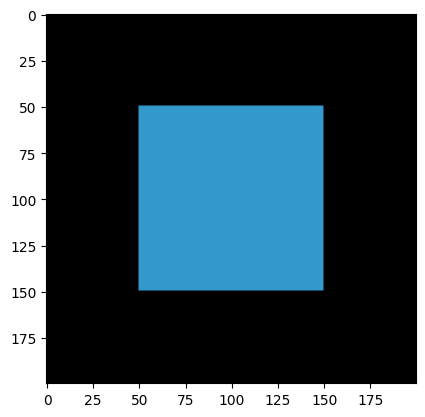

In [ ]:
img = np.zeros((200, 200, 3), np.float32)

img[50:150, 50:150,0] = 0.8
img[50:150, 50:150,1] = 0.6
img[50:150, 50:150,2] = 0.2

plt.imshow(img[...,::-1])

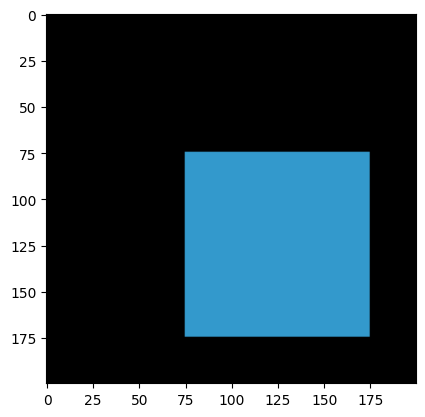

In [6]:
outDim = img.shape[0:2]

warpMat = np.float32([
    [1.0, 0.0, 25.0],
    [0.0, 1.0, 25.0]
])

result = cv2.warpAffine(img, warpMat, outDim)

plt.imshow(result[...,::-1])

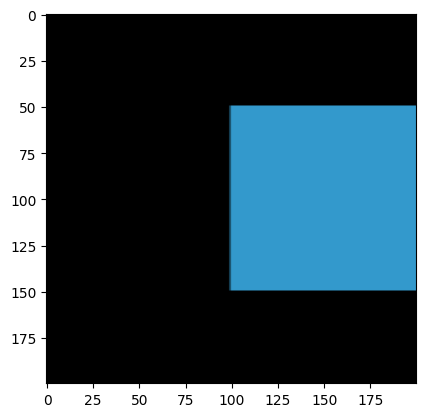

In [7]:
warpMat = np.float32([
    [2.0, 0.0, 0.0],
    [0.0, 1.0, 0.0]
])

result = cv2.warpAffine(img, warpMat, outDim)

plt.imshow(result[...,::-1])

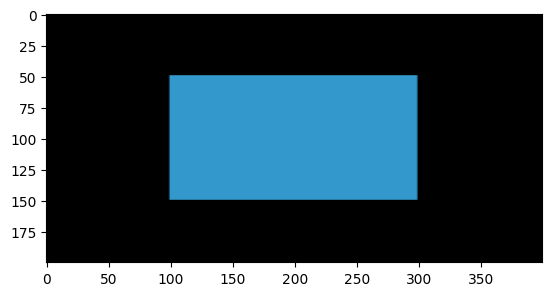

In [9]:
warpMat = np.float32([
    [2.0, 0.0, 0.0],
    [0.0, 1.0, 0.0]
])

result = cv2.warpAffine(img, warpMat, (2*outDim[0], outDim[1]))

plt.imshow(result[...,::-1])

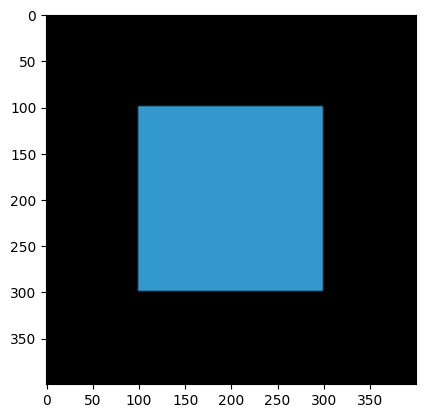

In [10]:
warpMat = np.float32([
    [2.0, 0.0, 0.0],
    [0.0, 2.0, 0.0]
])

result = cv2.warpAffine(img, warpMat, (2*outDim[0], 2*outDim[1]))

plt.imshow(result[...,::-1])

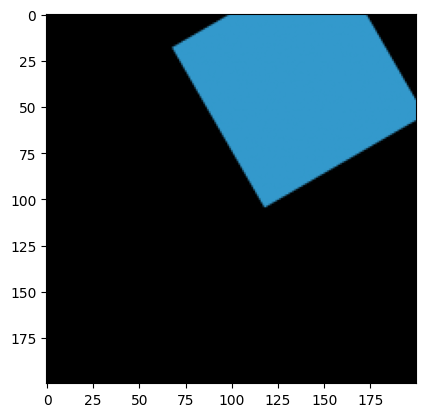

In [14]:
angleInDegrees = 30.0
angleInRadians = angleInDegrees * np.pi / 180.0

cosTheta = np.cos(angleInRadians)
sinTheta = np.sin(angleInRadians)

warpMat = np.float32([
    [cosTheta, sinTheta, 0.0],
    [-sinTheta, cosTheta, 0.0]
])

result = cv2.warpAffine(img, warpMat, outDim)

plt.imshow(result[...,::-1])

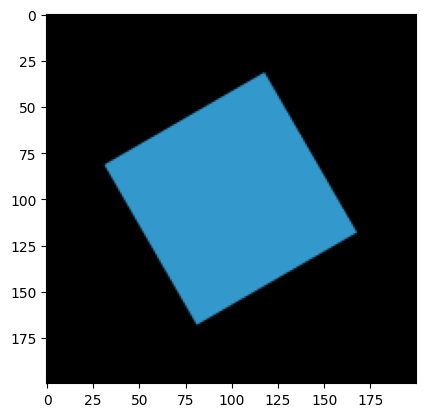

In [15]:
angleInDegrees = 30.0
angleInRadians = angleInDegrees * np.pi / 180.0

cosTheta = np.cos(angleInRadians)
sinTheta = np.sin(angleInRadians)

centerX = img.shape[0] / 2
centerY = img.shape[1] / 2

tx = (1 - cosTheta) * centerX - sinTheta * centerY
ty = sinTheta * centerX + (1 - cosTheta) * centerY

warpMat = np.float32([
    [cosTheta, sinTheta, tx],
    [-sinTheta, cosTheta, ty]
])

result = cv2.warpAffine(img, warpMat, outDim)

plt.imshow(result[...,::-1])

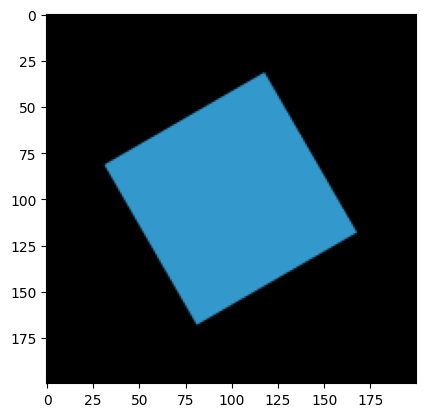

In [16]:
rotationMat = cv2.getRotationMatrix2D((centerX, centerY), angleInDegrees, 1)

result = cv2.warpAffine(img, rotationMat, outDim)

plt.imshow(result[...,::-1])

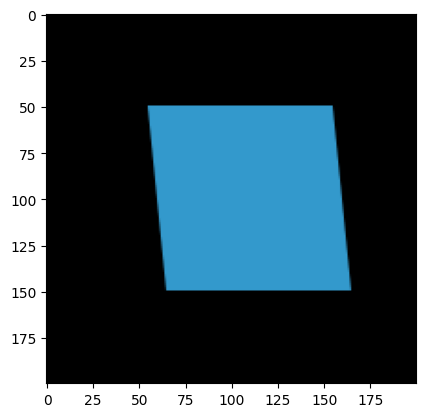

In [19]:
shearAmount = 0.1

warpMat = np.float32([
    [1.0, shearAmount, 0.0],
    [0.0, 1.0, 0.0]
])

result = cv2.warpAffine(img, warpMat, (outDim), None, flags = cv2.INTER_LINEAR)

plt.imshow(result[...,::-1])

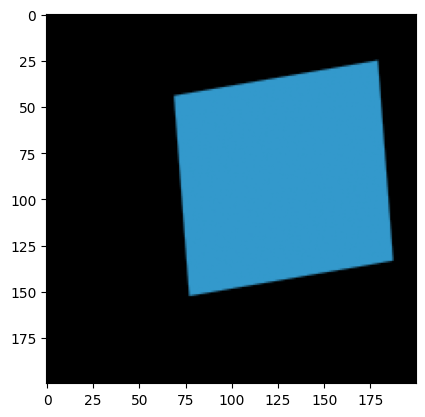

In [23]:
# Scale
scaleAmount = 1.1
scaleMat = np.float32([
    [scaleAmount, 0.0],
    [0.0, scaleAmount]
])

# Shear
shearAmount = -0.1
shearMat = np.float32([
    [1.0, shearAmount],
    [0.0, 1.0]
])

# Rotate
angleInRadians = 10.0 * np.pi / 180.0
cosTheta = np.cos(angleInRadians)
sinTheta = np.sin(angleInRadians)

rotationMat = np.float32([
    [cosTheta, sinTheta],
    [-sinTheta, cosTheta]
])

translateVector = np.float32([
    [10],
    [0]
])

scaleShearRotate = shearMat @ rotationMat @ scaleMat

warpMat = np.append(scaleShearRotate, translateVector, axis = 1)
# print(warpMat)
outPts = scaleShearRotate @ np.float32([[50,50], [50, 150], [150, 50], [150, 150]]).T + translateVector
# print(outPts)

result = cv2.warpAffine(img , warpMat, outDim)

plt.imshow(result[...,::-1])

In [34]:
# can use 3 points to compute affine transform as 
# it has 6 degrees of freedom and 3 points give
#  us 6 equations to solve for the 6 unknowns in 
# the affine transform matrix

srcPts = np.float32([[50,50], [50, 150], [150, 50]])
dstPts = np.float32([[68, 45], [76, 155], [176, 27]])

estimatedMat = cv2.estimateAffine2D(srcPts, dstPts)[0]
print("True warp matrix:\n", warpMat)
print("Estimated warp matrix:\n", estimatedMat)

True warp matrix:
 [[ 1.1023899   0.08268414 10.        ]
 [-0.191013    1.0832886   0.        ]]
Estimated warp matrix:
 [[ 1.08  0.08 10.  ]
 [-0.18  1.1  -1.  ]]


Estimated homography:
 [[ 3.94358182e-01 -4.04438664e-01  6.02613609e+01]
 [ 0.00000000e+00  1.91122673e-01  3.02820909e+01]
 [ 0.00000000e+00 -4.06471019e-03  1.00000000e+00]]


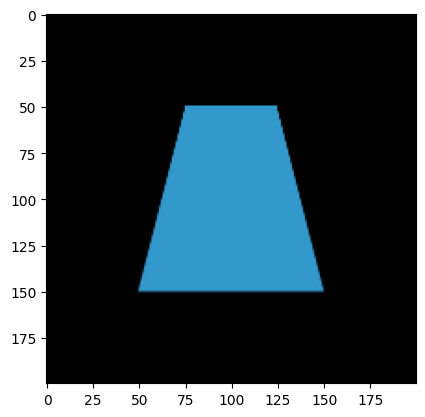

In [38]:
# limitations of affine transform is that it cannot transform 
# into any quadrilateral, like trapezium
# for example, checkout `https://courses.opencv.org/courses/course-v1:OpenCV.org+OpenCV-103+2019_T1/courseware/8a9d8d3a888141eeb7a41b5ebe63d6b6/d20a8385fc7d481ca94d41cfca14d44a/2?activate_block_id=block-v1%3AOpenCV.org%2BOpenCV-103%2B2019_T1%2Btype%40video%2Bblock%409d1ad4beb86e4685a58f8b7d66ca51bf`

srcPts = np.float32([[50,50], [50, 149], [149, 149], [149,50]])
dstPts = np.float32([[75, 50],[50, 149], [149, 149], [124, 50]])

h, status = cv2.findHomography(srcPts, dstPts)
print("Estimated homography:\n", h)

imH = cv2.warpPerspective(img, h, outDim)

plt.imshow(imH[...,::-1])

In [39]:
# Read source image.
im_src = cv2.imread('data/images/book2.jpg')
# Four corners of the book in source image
pts_src = np.array([[141, 131], [480, 159], [493, 630],[64, 601]], dtype=float)


# Read destination image.
im_dst = cv2.imread('data/images/book1.jpg')
# Four corners of the book in destination image.
pts_dst = np.array([[318, 256],[534, 372],[316, 670],[73, 473]], dtype=float)

# Calculate Homography
h, status = cv2.findHomography(pts_src, pts_dst)

# Warp source image to destination based on homography
im_out = cv2.warpPerspective(im_src, h, (im_dst.shape[1],im_dst.shape[0]))

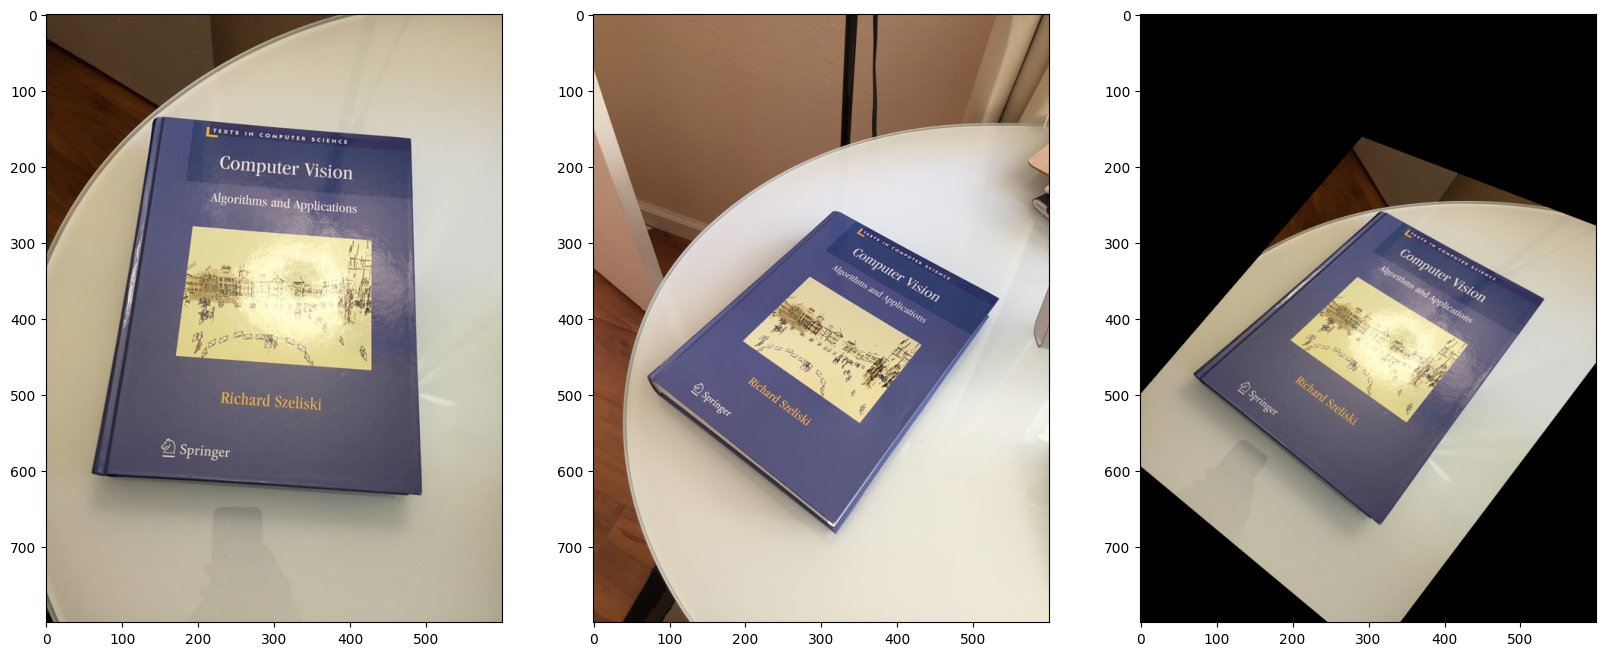

In [40]:
# Display images
plt.figure(figsize=[20,10])
plt.subplot(131)
plt.imshow(im_src[...,::-1])

plt.subplot(132)
plt.imshow(im_dst[...,::-1])

plt.subplot(133)
plt.imshow(im_out[...,::-1])

### Detecting Image Features

In [42]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

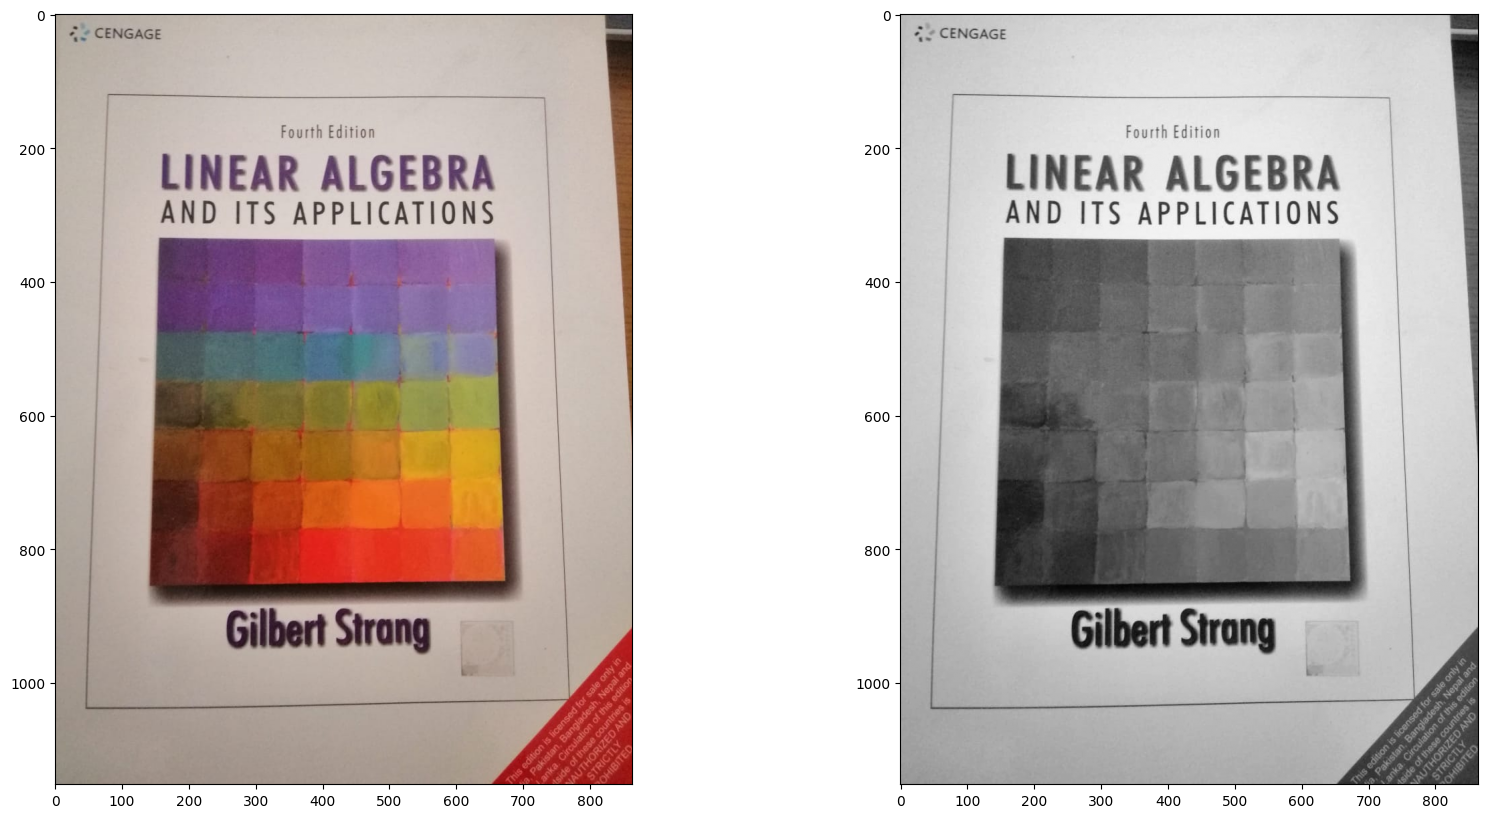

In [43]:
img = cv2. imread('data/images/book.jpeg')
imgGray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

plt.figure(figsize=[20,10])
plt.subplot(121);plt.imshow(img[..., ::-1])
plt.subplot(122);plt.imshow(imgGray, cmap='gray')

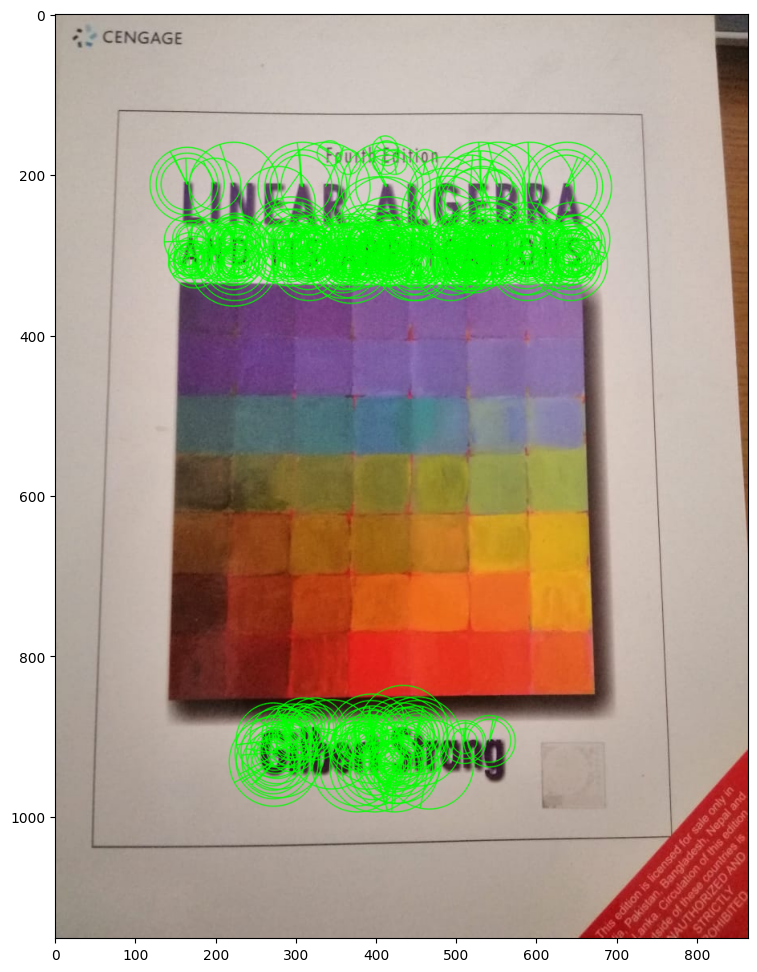

In [45]:
orb = cv2.ORB_create()

# detecting the keypoints with ORB
kp = orb.detect(imgGray, None)

# computing the descriptors with ORB
kp, des = orb.compute(imgGray, kp)

img2 = cv2.drawKeypoints(img, kp, None, color=(0,255,0), flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)

plt.figure(figsize=(12,12))
plt.imshow(img2[...,::-1])

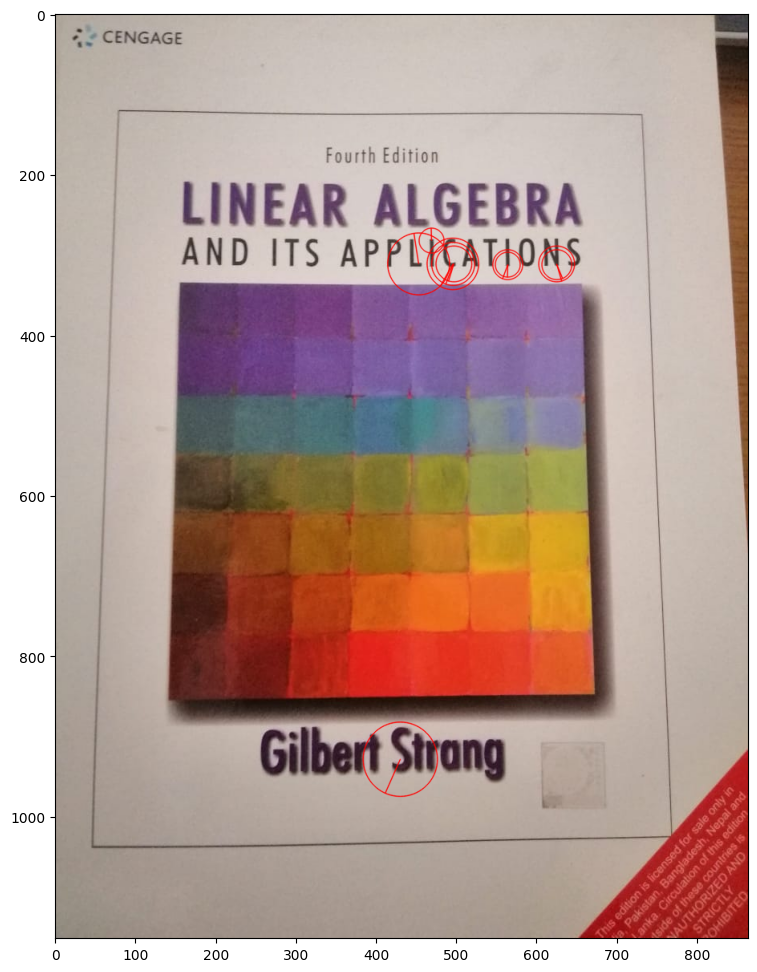

In [46]:
orb = cv2.ORB_create(10)
kp, des = orb.detectAndCompute(imgGray, None)
img2 = cv2.drawKeypoints(img, kp, None, color=(0,0,255), flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
plt.figure(figsize=(12,12))
plt.imshow(img2[:,:,::-1])

### Features Matching

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

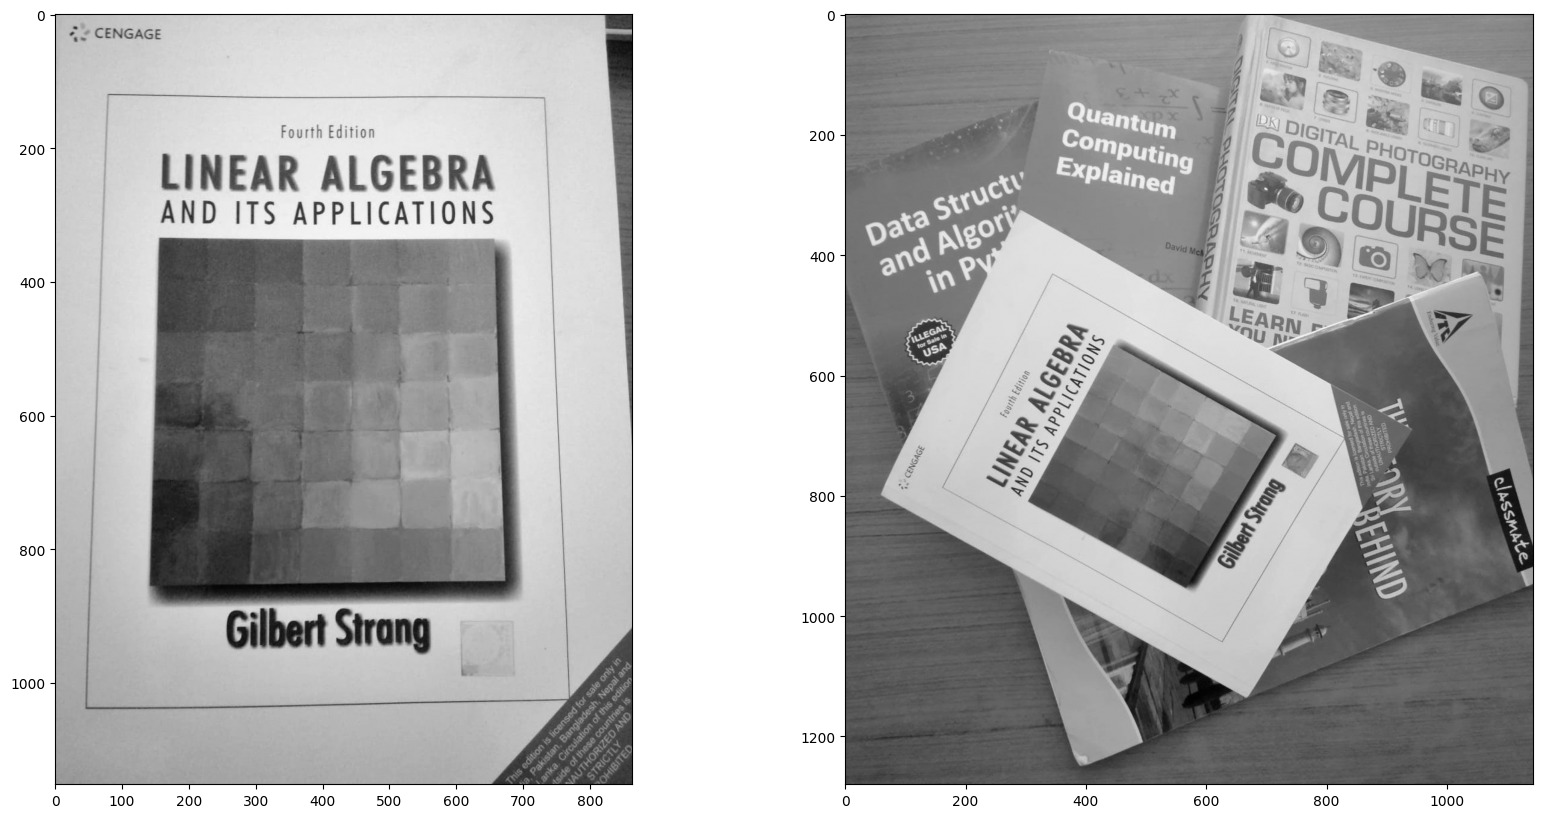

In [2]:
img1 = cv2.imread('data/images/book.jpeg', cv2.IMREAD_GRAYSCALE)
img2 = cv2.imread('data/images/book_scene.jpeg', cv2.IMREAD_GRAYSCALE)

plt.figure(figsize=[20,10])
plt.subplot(121);plt.imshow(img1, cmap='gray')
plt.subplot(122);plt.imshow(img2, cmap='gray')

In [3]:
orb = cv2.ORB_create()

kp1, des1 = orb.detectAndCompute(img1, None)
kp2, des2 = orb.detectAndCompute(img2, None)

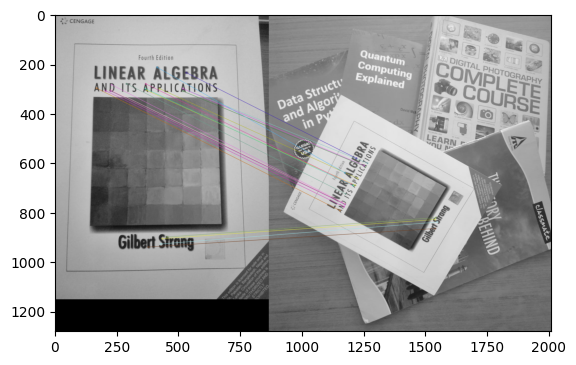

In [8]:
bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck = True)
matches = bf.match(des1, des2)
matches = sorted(matches, key=lambda x:x.distance)

img3 = cv2.drawMatches(img1, kp1, img2, kp2, matches[:20], None, flags=cv2.DRAW_MATCHES_FLAGS_NOT_DRAW_SINGLE_POINTS)

plt.imshow(img3)

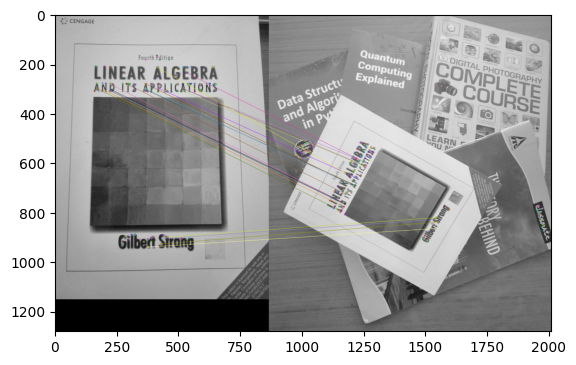

In [9]:
matcher = cv2.DescriptorMatcher_create(cv2.DESCRIPTOR_MATCHER_BRUTEFORCE_HAMMING)

matches = matcher.match(des1, des2)

matches = sorted(matches, key=lambda x:x.distance)

img3 = cv2.drawMatches(img1, kp1, img2, kp2, matches[:20], None)

plt.imshow(img3)

In [10]:
FLANN_INDEX_KDTREE = 1
index_params = dict(algorithm = FLANN_INDEX_KDTREE, trees = 5)
search_params = dict(checks=50)

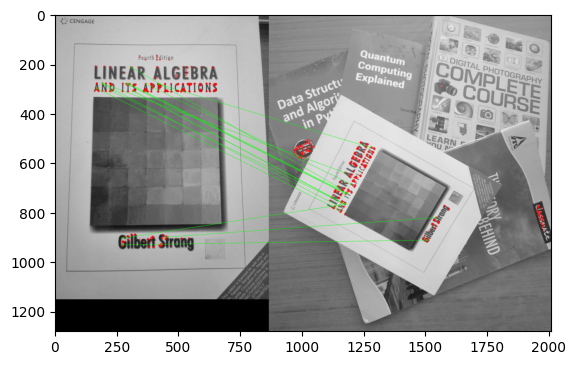

In [11]:
flann = cv2.FlannBasedMatcher(index_params, search_params)
matches = flann.knnMatch(np.float32(des1), np.float32(des2), k=2)

matchesMask = [[0,0] for i in range(len(matches))]

for i, (m,n) in enumerate(matches):
    if m.distance < 0.7*n.distance:
        matchesMask[i] = [1,0]

draw_params = dict(matchColor = (0,255,0), 
                   singlePointColor = (255,0,0),
                   matchesMask = matchesMask,
                   flags = cv2.DrawMatchesFlags_DEFAULT)

img3 = cv2.drawMatchesKnn(img1, kp1, img2, kp2, matches, None, **draw_params)

plt.imshow(img3)